In [1]:
!pip install -q sentence-transformers faiss-cpu

In [2]:
import re
import string
import numpy as np
import pandas as pd
import torch
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [3]:
df_raw = pd.read_csv("/content/dev-v1.1.csv")
print(df_raw.shape)

(48, 9825)


In [4]:
# Patterns to recognize the column names we need
ctx_pat = re.compile(r"paragraphs/(\d+)/context$")
q_pat = re.compile(r"paragraphs/(\d+)/qas/(\d+)/question$")

paragraph_rows, qa_rows = [], []

for art_idx, row in df_raw.iterrows():
    title = row["title"]
    for col in df_raw.columns:
        # Collect paragraphs (the knowledge base)
        m = ctx_pat.match(col)
        if m and pd.notna(row[col]):
            paragraph_rows.append({
                "article_id": art_idx, "title": title,
                "para_idx": int(m.group(1)), "context": row[col],
            })
        # Collect questions with their ground-truth answers
        m = q_pat.match(col)
        if m and pd.notna(row[col]):
            p, q = int(m.group(1)), int(m.group(2))
            base = f"paragraphs/{p}/qas/{q}"
            answers, a = [], 0
            while f"{base}/answers/{a}/text" in df_raw.columns:
                val = row[f"{base}/answers/{a}/text"]
                if pd.notna(val):
                    answers.append(str(val))
                a += 1
            qa_rows.append({
                "qid": row[f"{base}/id"], "article_id": art_idx, "title": title,
                "para_idx": p, "question": row[col], "answers": answers,
            })

paragraphs_df = pd.DataFrame(paragraph_rows)
paragraphs_df["context_id"] = range(len(paragraphs_df))

# Link every question to the paragraph that contains its answer
qa_df = pd.DataFrame(qa_rows).merge(
    paragraphs_df[["article_id", "para_idx", "context_id"]],
    on=["article_id", "para_idx"], how="left",
)

print(paragraphs_df.shape, qa_df.shape)

(2067, 5) (10570, 7)


In [5]:
qa_df[["qid", "question", "answers", "context_id"]].head()

,qid,question,answers,context_id
0,56be4db0acb8001400a502ec,Which NFL team represented the AFC at Super Bo...,"[Denver Broncos, Denver Broncos, Denver Broncos]",0
1,56be4db0acb8001400a502ed,Which NFL team represented the NFC at Super Bo...,"[Carolina Panthers, Carolina Panthers, Carolin...",0
2,56be4db0acb8001400a502ee,Where did Super Bowl 50 take place?,"[Santa Clara, California, Levi's Stadium, Levi...",0
3,56be4db0acb8001400a502ef,Which NFL team won Super Bowl 50?,"[Denver Broncos, Denver Broncos, Denver Broncos]",0
4,56be4db0acb8001400a502f0,What color was used to emphasize the 50th anni...,"[gold, gold, gold]",0


In [6]:
# Add helpful length columns
paragraphs_df["n_words"] = paragraphs_df["context"].str.split().str.len()
qa_df["q_words"] = qa_df["question"].str.split().str.len()
qa_df["a_words"] = qa_df["answers"].apply(lambda a: len(a[0].split()) if a else 0)
qa_df["q_type"] = qa_df["question"].str.split().str[0].str.lower()

# Data quality check
print("Duplicate paragraphs:", paragraphs_df["context"].duplicated().sum())

# Paragraph length
print("\nParagraph length (words):")
print(paragraphs_df["n_words"].describe().round(1))

# Question and answer length
print("\nQuestion and answer length (words):")
print(qa_df[["q_words", "a_words"]].describe().round(1))

# Questions per article
q_per_article = qa_df.groupby("title").size().sort_values(ascending=False)
print("\nTop 3 articles by number of questions:")
print(q_per_article.head(3))

# What kind of questions are asked
print("\nMost common first words of questions:")
print(qa_df["q_type"].value_counts().head(8))

Duplicate paragraphs: 0

Paragraph length (words):
count    2067.0
mean      122.8
std        54.8
min        22.0
25%        90.0
50%       111.0
75%       144.0
max       629.0
Name: n_words, dtype: float64

Question and answer length (words):
       q_words  a_words
count  10570.0  10570.0
mean      10.2      3.0
std        3.6      3.0
min        3.0      0.0
25%        8.0      1.0
50%       10.0      2.0
75%       12.0      3.0
max       33.0     29.0

Top 3 articles by number of questions:
title
Super_Bowl_50    810
Nikola_Tesla     511
Martin_Luther    479
dtype: int64

Most common first words of questions:
q_type
what     4749
how      1090
who      1059
when      696
which     454
in        443
where     433
the       237
Name: count, dtype: int64


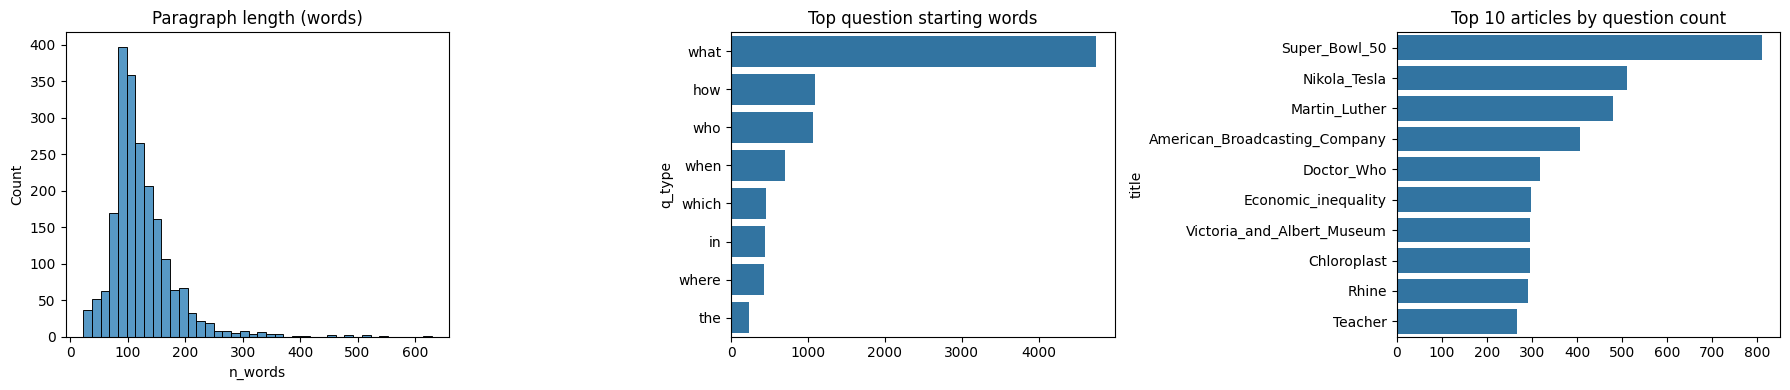

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(paragraphs_df["n_words"], bins=40, ax=axes[0])
axes[0].set_title("Paragraph length (words)")

top = qa_df["q_type"].value_counts().head(8)
sns.barplot(x=top.values, y=top.index, ax=axes[1])
axes[1].set_title("Top question starting words")

top_art = q_per_article.head(10)
sns.barplot(x=top_art.values, y=top_art.index, ax=axes[2])
axes[2].set_title("Top 10 articles by question count")

plt.tight_layout()
plt.show()

In [8]:
def clean_text(text):
    # Replace any run of spaces or line breaks with one space
    return re.sub(r"\s+", " ", text).strip()

paragraphs_df["text"] = paragraphs_df["context"].apply(clean_text)
documents = paragraphs_df["text"].tolist()

print("Total documents:", len(documents))
print(documents[0][:200])

Total documents: 2067
Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated


In [9]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

embeddings = embed_model.encode(
    documents,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
).astype("float32")

print(embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/33 [00:00<?, ?it/s]

(2067, 384)


In [10]:
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

print("Vectors stored:", index.ntotal)

Vectors stored: 2067


In [11]:
def retrieve(question, k=3):
    q_emb = embed_model.encode([question], normalize_embeddings=True).astype("float32")
    scores, ids = index.search(q_emb, k)
    return [
        {"context_id": int(i), "score": round(float(s), 3), "text": documents[i]}
        for s, i in zip(scores[0], ids[0])
    ]

In [12]:
question = "Which NFL team represented the AFC at Super Bowl 50?"

for r in retrieve(question, k=3):
    print("context_id:", r["context_id"], "| score:", r["score"])
    print(r["text"][:200], "\n")

context_id: 0 | score: 0.698
Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated 

context_id: 1 | score: 0.627
The Panthers finished the regular season with a 15–1 record, and quarterback Cam Newton was named the NFL Most Valuable Player (MVP). They defeated the Arizona Cardinals 49–15 in the NFC Championship  

context_id: 22 | score: 0.552
As the designated home team in the annual rotation between AFC and NFC teams, the Broncos elected to wear their road white jerseys with matching white pants. Elway stated, "We've had Super Bowl succes 



In [13]:
questions = qa_df["question"].tolist()

q_embs = embed_model.encode(
    questions,
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True,
).astype("float32")

_, ids = index.search(q_embs, 10)
true_ids = qa_df["context_id"].values

recall_results = {}
for k in [1, 3, 5, 10]:
    hit_rate = (ids[:, :k] == true_ids[:, None]).any(axis=1).mean()
    recall_results[k] = hit_rate
    print(f"Recall@{k}: {hit_rate:.4f}  ({hit_rate*100:.2f}%)")

Batches:   0%|          | 0/83 [00:00<?, ?it/s]

Recall@1: 0.6251  (62.51%)
Recall@3: 0.8077  (80.77%)
Recall@5: 0.8640  (86.40%)
Recall@10: 0.9172  (91.72%)


In [14]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

gen_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(gen_name)
generator = AutoModelForSeq2SeqLM.from_pretrained(gen_name).to(device)
generator.eval()

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [15]:
def build_prompt(question, contexts):
    # Question comes first so it is never cut if the context is long
    context_text = "\n\n".join(contexts)
    return (
        "Answer the question using only the context. Give a short answer.\n"
        f"Question: {question}\n\n"
        f"Context: {context_text}"
    )

def generate_batch(prompts, max_new_tokens=32):
    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True,
    ).to(device)
    with torch.no_grad():
        out = generator.generate(**inputs, max_new_tokens=max_new_tokens)
    return tokenizer.batch_decode(out, skip_special_tokens=True)

def rag_answer(question, k=3):
    retrieved = retrieve(question, k=k)
    contexts = [r["text"] for r in retrieved]
    answer = generate_batch([build_prompt(question, contexts)])[0]
    return {
        "question": question,
        "answer": answer,
        "retrieved_ids": [r["context_id"] for r in retrieved],
    }

In [16]:
for i in [0, 1, 2, 500, 5000]:
    out = rag_answer(qa_df.loc[i, "question"])
    print("Q:", out["question"])
    print("RAG answer:", out["answer"])
    print("True answers:", qa_df.loc[i, "answers"])
    print("Correct paragraph id:", qa_df.loc[i, "context_id"], "| Retrieved:", out["retrieved_ids"])
    print("-" * 60)

Q: Which NFL team represented the AFC at Super Bowl 50?
RAG answer: Denver Broncos
True answers: ['Denver Broncos', 'Denver Broncos', 'Denver Broncos']
Correct paragraph id: 0 | Retrieved: [0, 1, 22]
------------------------------------------------------------
Q: Which NFL team represented the NFC at Super Bowl 50?
RAG answer: Denver Broncos
True answers: ['Carolina Panthers', 'Carolina Panthers', 'Carolina Panthers']
Correct paragraph id: 0 | Retrieved: [0, 1, 22]
------------------------------------------------------------
Q: Where did Super Bowl 50 take place?
RAG answer: Levi's Stadium
True answers: ['Santa Clara, California', "Levi's Stadium", "Levi's Stadium in the San Francisco Bay Area at Santa Clara, California."]
Correct paragraph id: 0 | Retrieved: [0, 7, 28]
------------------------------------------------------------
Q: What was media day called for Super Bowl 50?
RAG answer: Super Bowl Opening Night
True answers: ['Super Bowl Opening Night.', 'Super Bowl Opening Night', '

In [17]:
def normalize_text(s):
    s = s.lower()
    s = "".join(ch for ch in s if ch not in set(string.punctuation))
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    return " ".join(s.split())

def exact_match(pred, golds):
    return max(float(normalize_text(pred) == normalize_text(g)) for g in golds)

def f1_single(pred, gold):
    p, g = normalize_text(pred).split(), normalize_text(gold).split()
    common = Counter(p) & Counter(g)
    n_same = sum(common.values())
    if len(p) == 0 or len(g) == 0:
        return float(p == g)
    if n_same == 0:
        return 0.0
    prec, rec = n_same / len(p), n_same / len(g)
    return 2 * prec * rec / (prec + rec)

def f1_score(pred, golds):
    return max(f1_single(pred, g) for g in golds)

In [18]:
eval_df = qa_df[qa_df["answers"].str.len() > 0].sample(500, random_state=42).reset_index(drop=True)

# Retrieve top-3 paragraphs for all sampled questions at once
eq = embed_model.encode(
    eval_df["question"].tolist(), batch_size=128, normalize_embeddings=True
).astype("float32")
_, top_ids = index.search(eq, 3)

prompts = [
    build_prompt(q, [documents[i] for i in row])
    for q, row in zip(eval_df["question"], top_ids)
]

# Generate answers in small batches
preds = []
for start in tqdm(range(0, len(prompts), 16)):
    preds += generate_batch(prompts[start:start + 16])

eval_df["prediction"] = preds
eval_df["EM"] = [exact_match(p, g) for p, g in zip(preds, eval_df["answers"])]
eval_df["F1"] = [f1_score(p, g) for p, g in zip(preds, eval_df["answers"])]

print(f"Exact Match: {eval_df['EM'].mean():.4f}  ({eval_df['EM'].mean()*100:.2f}%)")
print(f"F1 score:    {eval_df['F1'].mean():.4f}  ({eval_df['F1'].mean()*100:.2f}%)")

  0%|          | 0/32 [00:00<?, ?it/s]

Exact Match: 0.6540  (65.40%)
F1 score:    0.7422  (74.22%)


In [19]:
eval_df[eval_df["EM"] == 0][["question", "prediction", "answers"]].head(10)

,question,prediction,answers
5,Who discovered this and where did they come from?,the Persian scholar Ibn Sina,[Michael Heckenberger and colleagues of the Un...
15,What type of ratios are used in geochronologic...,isotope ratios,"[isotope ratios of radioactive elements, isoto..."
19,What group of people cannot be part of civil d...,civil disobedients,"[sovereign branches of government, public offi..."
20,When were the Daleks reintroduced in the reviv...,2005,"[series 1, series 1, series 1,]"
25,What month and year was Apollo 13 launched?,December 1968,"[April 1970, April, April 1970, April 1970, Ap..."
26,Why did Warsaw become the capital of the Commo...,Due to its central location between the Common...,"[Due to its central location, its central loca..."
27,How many Muslims came from around the world to...,"an estimated 16,000 to 35,000","[16,000 to 35,000, 16,000 to 35,000, 16,000 to..."
29,What team did the Panthers defeat?,Seattle Seahawks,"[Arizona Cardinals, the Arizona Cardinals, Ari..."
31,Where did the family move in 1862?,Charleston Orange district,"[Gospić, Austrian Empire, Gospić, Gospić]"
33,Why are people who distribute leaflets inside ...,solitary civil disobedience,[the leaflets will have to be given to the lea...


In [23]:
my_question = "what is rag ?"   # change this and run again

result = rag_answer(my_question)

print("Question:", result["question"])
print("RAG answer:", result["answer"])
print("\nTop source paragraph (id", result["retrieved_ids"][0], "):")
print(documents[result["retrieved_ids"][0]][:300], "...")

Question: what is rag ?
RAG answer: a weaving school

Top source paragraph (id 545 ):
Other evidence of the Walloons and Huguenots in Canterbury includes a block of houses in Turnagain Lane, where weavers' windows survive on the top floor, as many Huguenots worked as weavers. The Weavers, a half-timbered house by the river, was the site of a weaving school from the late 16th century  ...


In [24]:
print("RETRIEVAL (all", len(qa_df), "questions)")
for k, v in recall_results.items():
    print(f"  Recall@{k}: {v*100:.2f}%")

print("\nFULL RAG (random sample of 500 questions, top-3 paragraphs)")
print(f"  Exact Match: {eval_df['EM'].mean()*100:.2f}%")
print(f"  F1 score:    {eval_df['F1'].mean()*100:.2f}%")

RETRIEVAL (all 10570 questions)
  Recall@1: 62.51%
  Recall@3: 80.77%
  Recall@5: 86.40%
  Recall@10: 91.72%

FULL RAG (random sample of 500 questions, top-3 paragraphs)
  Exact Match: 65.40%
  F1 score:    74.22%
